In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error, r2_score

In [72]:
df= pd.read_csv('cleaned_mymovies_db.csv')
df.columns

Index(['release_date', 'title', 'overview', 'popularity', 'vote_count',
       'vote_average', 'original_language', 'orig_genre', 'poster_url',
       'release_year', 'popularity_scaled', 'vote_count_scaled'],
      dtype='object')

In [73]:
df['movie_age']= df['release_year'].max() - df['release_year']

In [74]:
df

,release_date,title,overview,popularity,vote_count,vote_average,original_language,orig_genre,poster_url,release_year,popularity_scaled,vote_count_scaled,movie_age
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021,5.646152,9.098403,3
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022,5.646152,7.049255,2
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022,5.646152,4.812184,2
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021,5.646152,8.532476,3
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021,5.646152,7.492203,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9822,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...,1973,2.664238,6.799056,51
9823,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...,2020,2.664168,2.197225,4
9824,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...,2016,2.664098,4.553877,8
9825,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...,2021,2.664029,5.030438,3


In [75]:
X= df[['vote_average', 'vote_count_scaled', 'original_language', 'orig_genre', 'movie_age']]
y= df[['popularity_scaled']]

In [76]:
X_train, X_test, y_train, y_test= train_test_split(X, y, random_state=42, test_size= 0.2)

In [77]:
#printing shapes
print(f'Shape of X_train= {X_train.shape}')
print(f'Shape of y_train= {y_train.shape}')
print(f'Shape of X_test= {X_test.shape}')
print(f'Shape of y_test= {y_test.shape}')

Shape of X_train= (7861, 5)
Shape of y_train= (7861, 1)
Shape of X_test= (1966, 5)
Shape of y_test= (1966, 1)


In [78]:
#Scaling numeric train data
avg_rating_scaler = StandardScaler()
vote_count_scaler = StandardScaler()
movies_age_scaler= StandardScaler()

X_train['vote_average'] = avg_rating_scaler.fit_transform(X_train[['vote_average']])
X_train['vote_count_scaled'] = vote_count_scaler.fit_transform(X_train[['vote_count_scaled']])
X_train['movie_age']= movies_age_scaler.fit_transform(X_train[['movie_age']])

In [79]:
#Encoding categorical data
language_encoder= OneHotEncoder(handle_unknown= 'ignore', sparse_output= False)
language_encoded= language_encoder.fit_transform(X_train[['original_language']])
language_encoded_df= pd.DataFrame(
    language_encoded, 
    columns= language_encoder.get_feature_names_out(['original_language']),
    index= X_train.index
    )



In [80]:
genre_binarizer= MultiLabelBinarizer()

genre= X_train['orig_genre'].str.split(', ')
encoded_genre= genre_binarizer.fit_transform(genre)
genre_df= pd.DataFrame(
    encoded_genre,
    columns= genre_binarizer.classes_,
    index= X_train.index
)

In [81]:
X_train= pd.merge(X_train, language_encoded_df, left_index= True, right_index= True)
X_train= pd.merge(X_train, genre_df, left_index= True, right_index= True)

X_train= X_train.drop(columns= ['orig_genre', 'original_language'])

In [82]:
#scaling y values
popularity_scaler= StandardScaler()
y_train = popularity_scaler.fit_transform(y_train) 

In [83]:
#training model
model= Ridge(alpha= 0.1)
model.fit(X_train, y_train) 

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [84]:
X_test['vote_average'] = avg_rating_scaler.transform(X_test[['vote_average']])
X_test['vote_count_scaled'] = vote_count_scaler.transform(X_test[['vote_count_scaled']])
X_test['movie_age']= movies_age_scaler.transform(X_test[['movie_age']])

In [85]:
encoded_lang= language_encoder.transform(X_test[['original_language']])
encoded_lang_df= pd.DataFrame(
    encoded_lang, 
    columns= language_encoder.get_feature_names_out(['original_language']),
    index= X_test.index
    )

In [86]:
test_genre= X_test['orig_genre'].str.split(', ')
encoded_test_genre= genre_binarizer.transform(test_genre)
test_genre_df= pd.DataFrame(
    encoded_test_genre,
    columns= genre_binarizer.classes_,
    index= X_test.index
)

In [87]:
X_test= pd.merge(X_test, encoded_lang_df, left_index= True, right_index= True)
X_test= pd.merge(X_test, test_genre_df, left_index= True, right_index= True)

X_test= X_test.drop(columns= ['orig_genre', 'original_language'])

In [88]:
# making predictions
y_test = popularity_scaler.transform(y_test) 
y_pred= model.predict(X_test)

In [89]:
rmse= root_mean_squared_error(y_test, y_pred)
r2_score= r2_score(y_test, y_pred)

In [90]:
print(f'r2 score= {r2_score}')
print(f'rmse score= {rmse}')

r2 score= 0.19529936721778562
rmse score= 0.9211501116200012


<Axes: >

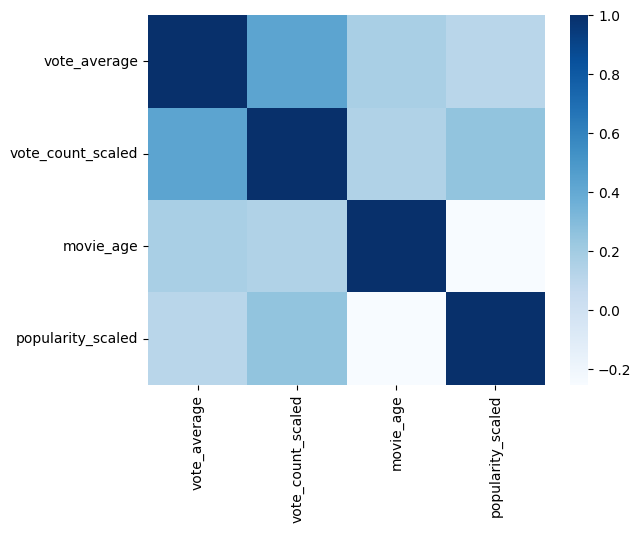

In [91]:
corr= df[['vote_average', 'vote_count_scaled', 'original_language', 'orig_genre', 'movie_age', 'popularity_scaled']].corr(numeric_only=True)
sns.heatmap(corr, cmap= 'Blues')

In [92]:
corr['popularity_scaled']

vote_average         0.108319
vote_count_scaled    0.254851
movie_age           -0.254399
popularity_scaled    1.000000
Name: popularity_scaled, dtype: float64

## This model gives ass predictions, because the input labels have little correlation with the output label

### 1) High rmse (0.92):-  
- y_train and y_test are standarized
- Predictions are off on average by 0.92 std
- WAY OFF

### 2) Low r2 score (0.19)
- The input features only describe 19% of the variance.
- extremely poor due to low correlation between input features and target variable.